# Import libraries

In [2]:

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import RandomOverSampler
from collections import Counter


import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, VGG16, InceptionV3, DenseNet121, MobileNetV2, Xception
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import shap
from shap import GradientExplainer
from shap.utils import sample
import skimage.segmentation

print("All libraries imported successfully!")

All libraries imported successfully!


# Load and pre-process

In [3]:

# Define dataset path 
dataset_path = '/kaggle/input/lung-ct-scans/Lung_CT'  

# Get class names from folder names
class_names = sorted(os.listdir(dataset_path))
print("Class names:", class_names)

# Load and preprocess images
def load_and_preprocess_images(folder_path, img_size=(224, 224)):
    images = []
    labels = []

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            # Load image
            image = load_img(image_path, target_size=img_size)
            image = img_to_array(image)

            # Normalize pixel values to [0, 1]
            image = image / 255.0

            images.append(image)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load all images
X, y = load_and_preprocess_images(dataset_path)
print("Dataset loaded successfully!")
print("Total images:", len(X))
print("Image shape:", X[0].shape)

Class names: ['Adenocarcinoma', 'Benign', 'Large_Cell_Carcinoma', 'Malignant', 'Normal', 'Squamous_Cell_Carcinoma']
Dataset loaded successfully!
Total images: 1997
Image shape: (224, 224, 3)


# Balanceing the each class

Class distribution: Counter({4: 575, 3: 561, 0: 326, 5: 252, 2: 163, 1: 120})


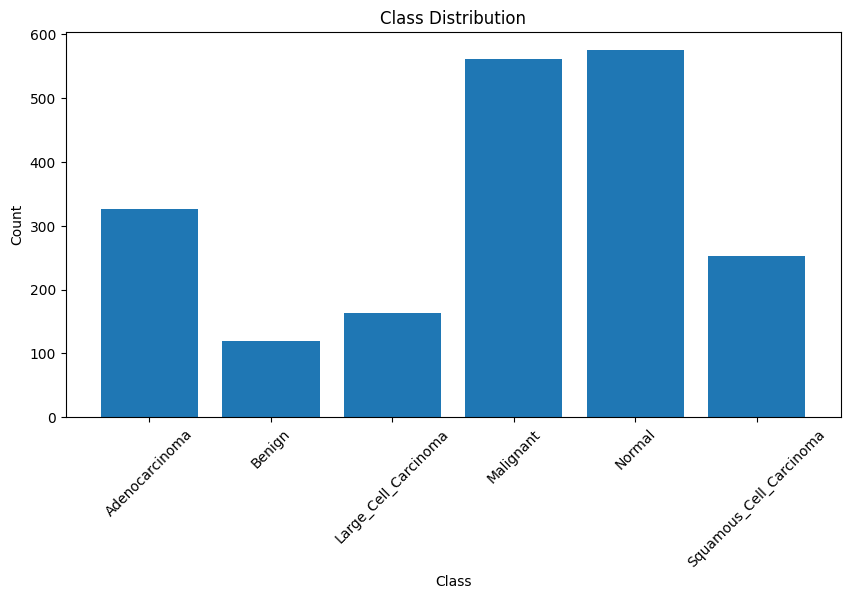

Applying oversampling to balance classes...
New class distribution: Counter({0: 575, 1: 575, 2: 575, 3: 575, 4: 575, 5: 575})


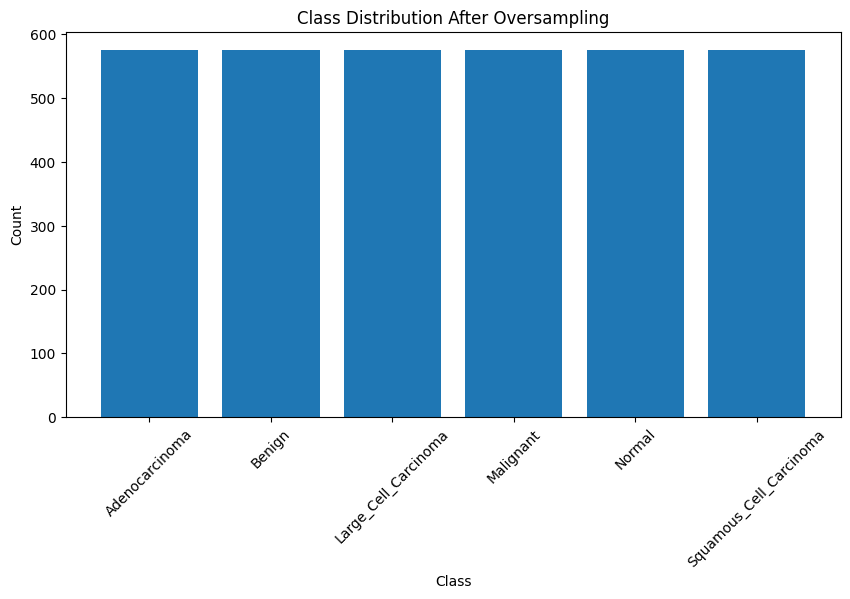

In [4]:
# Check class distribution
class_dist = Counter(y)
print("Class distribution:", class_dist)

# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, [class_dist[i] for i in range(len(class_names))])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Handle class imbalance with oversampling
if len(set(class_dist.values())) > 1:  # Check if classes are imbalanced
    print("Applying oversampling to balance classes...")
    X_reshaped = X.reshape(X.shape[0], -1)  # Flatten images for oversampler
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_reshaped, y)
    X = X_resampled.reshape(-1, *X.shape[1:])  # Reshape back to image dimensions
    y = y_resampled
    print("New class distribution:", Counter(y))

# display after balancing the dataset
# Visualize new class distribution after oversampling
plt.figure(figsize=(10, 5))
plt.bar(class_names, [Counter(y)[i] for i in range(len(class_names))])
plt.title("Class Distribution After Oversampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# Display some image

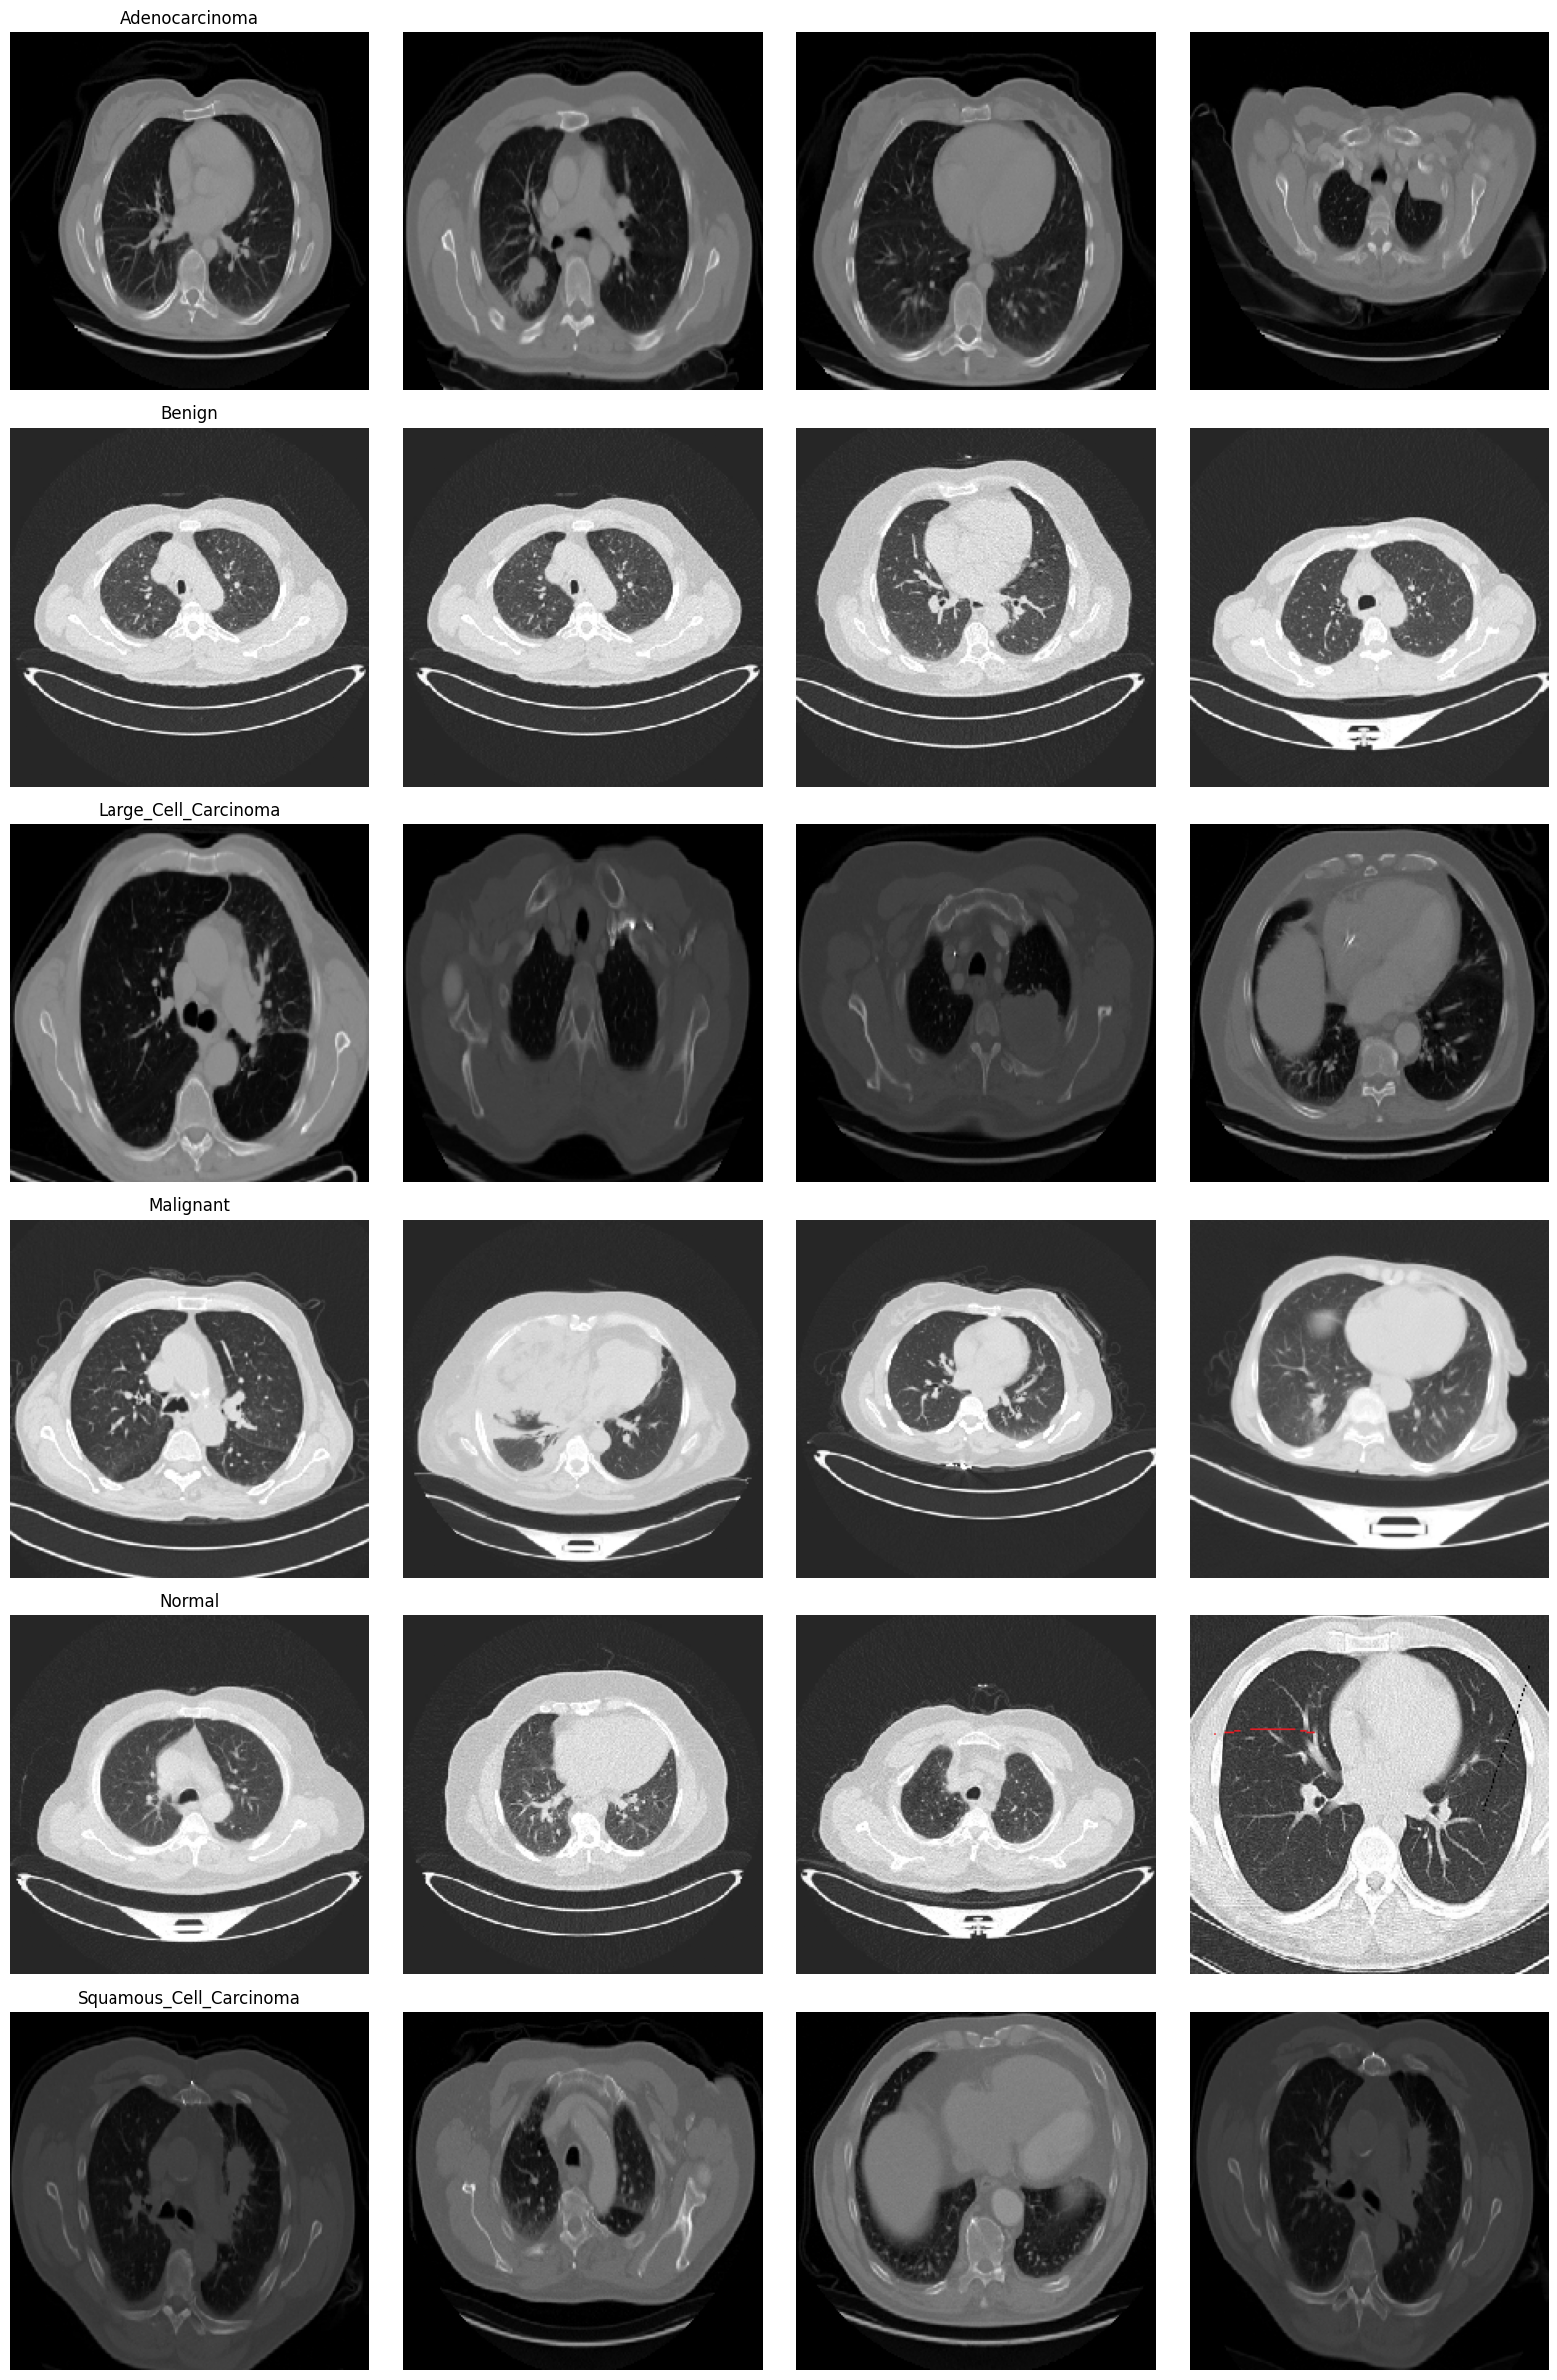

In [12]:
import random

# Visualize sample images from each class
plt.figure(figsize=(16, 4 * len(class_names)))  # Adjusted figure size: wider for 4 images, height based on number of classes

# Calculate grid dimensions
num_classes = len(class_names)
cols = 4  # 4 images per class
rows = num_classes  # One row per class

for class_idx, class_name in enumerate(class_names):
    # Get indices of images belonging to this class
    class_indices = np.where(y == class_idx)[0]  # Works with non-one-hot encoded y

    # Select 4 random images from this class (or fewer if not enough images)
    sample_indices = random.sample(list(class_indices), min(4, len(class_indices)))

    for j, idx in enumerate(sample_indices):
        # Create subplot position
        plt.subplot(rows, cols, class_idx * cols + j + 1)

        # Display image
        plt.imshow(X[idx])
        if j == 0:  # Only show title on first image of each row
            plt.title(f"{class_name}")
        else:
            plt.title("")
        plt.axis('off')

# Pad the remaining subplots if less than 4 images are available for any class
for class_idx, class_name in enumerate(class_names):
    class_indices = np.where(y == class_idx)[0]
    num_samples = len(sample_indices)
    if num_samples < 4:
        for j in range(num_samples, 4):
            plt.subplot(rows, cols, class_idx * cols + j + 1)
            plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Splitting dataset

In [8]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert labels to one-hot encoding
y_train_onehot = to_categorical(y_train, num_classes=len(class_names))
y_test_onehot = to_categorical(y_test, num_classes=len(class_names))

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (2760, 224, 224, 3)
Test set shape: (690, 224, 224, 3)


# Building cnn

In [19]:
# Define CNN model
def build_cnn_model(input_shape=(224, 224, 3), num_classes=len(class_names)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Build and train CNN model
cnn_model = build_cnn_model()
cnn_model.summary()

# Callbacks
checkpoint = ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = cnn_model.fit(X_train, y_train_onehot,
                        validation_data=(X_test, y_test_onehot),
                        epochs=30,
                        batch_size=32,
                        callbacks=[checkpoint, early_stopping])

# Load best model
cnn_model = load_model('best_cnn_model.keras')

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_199 (Conv2D)                  │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_200 (Conv2D)                  │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_201 (Conv2D)                  │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4222 - loss: 1.4471
Epoch 1: val_accuracy improved from -inf to 0.78986, saving model to best_cnn_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.4236 - loss: 1.4430 - val_accuracy: 0.7899 - val_loss: 0.5734
Epoch 2/30
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8060 - loss: 0.5208
Epoch 2: val_accuracy improved from 0.78986 to 0.93768, saving model to best_cnn_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.8066 - loss: 0.5189 - val_accuracy: 0.9377 - val_loss: 0.1996
Epoch 3/30
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9071 - loss: 0.2445
Epoch 3: val_accuracy improved from 0.93768 to 0.96232, saving model to best_cnn_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9073 - loss: 0.2442 - val_accuracy: 0.9623 - val_loss: 0.1243
Epoch 4/30
86/87 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9469 - loss: 0.1554
Epoch 4: val_accuracy improved fro

# Evaluation CNN


CNN Model Evaluation:
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Accuracy: 0.9884

Classification Report:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.97      0.98      0.98       115
                 Benign       0.98      0.99      0.99       115
   Large_Cell_Carcinoma       1.00      1.00      1.00       115
              Malignant       0.98      1.00      0.99       115
                 Normal       0.99      0.96      0.97       115
Squamous_Cell_Carcinoma       1.00      1.00      1.00       115

               accuracy                           0.99       690
              macro avg       0.99      0.99      0.99       690
           weighted avg       0.99      0.99      0.99       690



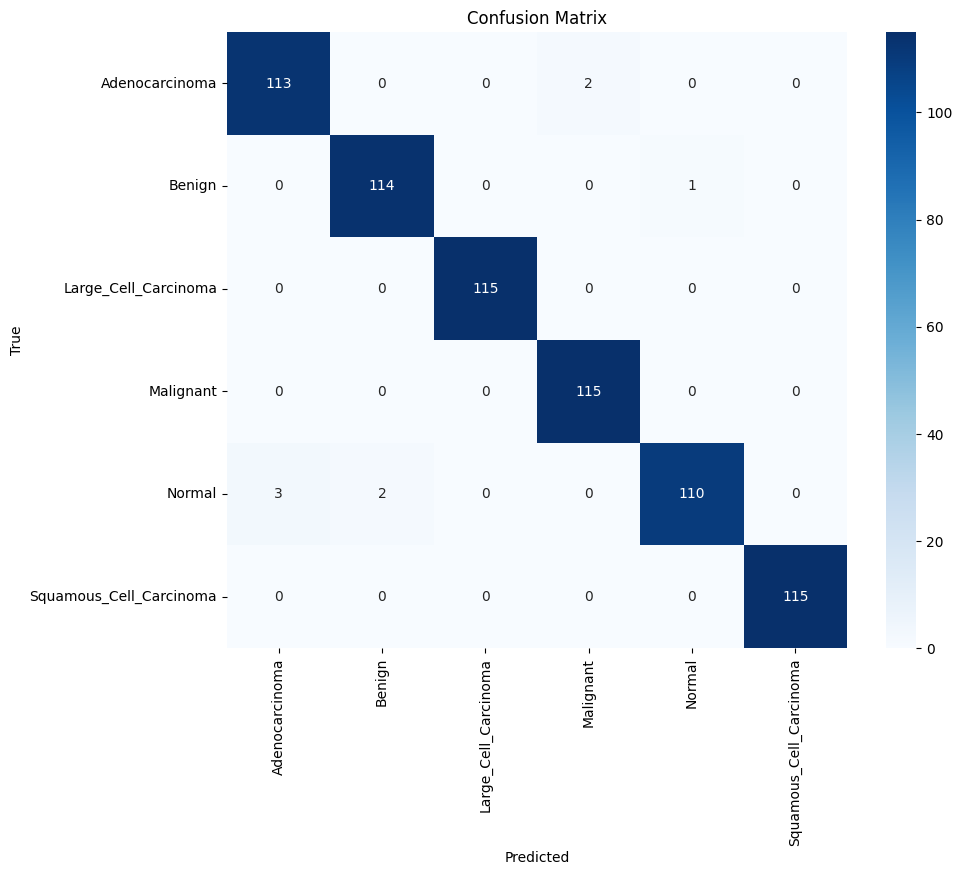

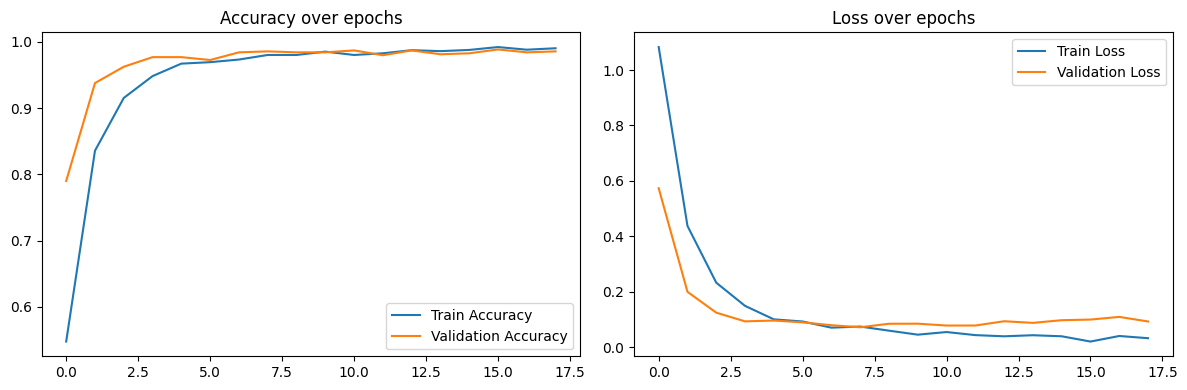

In [20]:
# Evaluate CNN model
def evaluate_model(model, X_test, y_test, y_test_onehot):
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred_classes)
    print(f"Accuracy: {accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_classes, target_names=class_names))

    # Confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Evaluate CNN model
print("CNN Model Evaluation:")
evaluate_model(cnn_model, X_test, y_test, y_test_onehot)

# Implement Transfer learning models

In [21]:
# Define Transfer Learning model builder
def build_transfer_model(base_model_fn, input_shape=(224, 224, 3), num_classes=len(class_names)):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks
checkpoint = ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Models to compare
models = {
    'VGG16': VGG16,
    'InceptionV3': InceptionV3,
    'MobileNetV2': MobileNetV2,
    'DenseNet121': DenseNet121,
    'Xception': Xception,
}

# Train and compare
histories = {}
for name, model_fn in models.items():
    print(f"\nTraining {name}...")
    transfer_model = build_transfer_model(model_fn)
    

    history = transfer_model.fit(X_train, y_train_onehot,
                                 validation_data=(X_test, y_test_onehot),
                                 epochs=30,
                                 batch_size=32,
                                 callbacks=[checkpoint, early_stopping])

    histories[name] = history
    transfer_model.save(f'{name}_model.keras')

# Load best model (Optional: depends on use case)
best_model = load_model('best_transfer_model.keras')



Training VGG16...
Epoch 1/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.2951 - loss: 1.6225
Epoch 1: val_accuracy improved from -inf to 0.49420, saving model to best_transfer_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 24s 253ms/step - accuracy: 0.2960 - loss: 1.6201 - val_accuracy: 0.4942 - val_loss: 1.1386
Epoch 2/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.5128 - loss: 1.0934
Epoch 2: val_accuracy improved from 0.49420 to 0.65072, saving model to best_transfer_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.5130 - loss: 1.0930 - val_accuracy: 0.6507 - val_loss: 0.9534
Epoch 3/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5727 - loss: 0.9683
Epoch 3: val_accuracy improved from 0.65072 to 0.66667, saving model to best_transfer_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 18s 203ms/step - accuracy: 0.5730 - loss: 0.9680 - val_accuracy: 0.6667 - val_loss: 0.8575
Epoch 4/30
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6303 - loss:

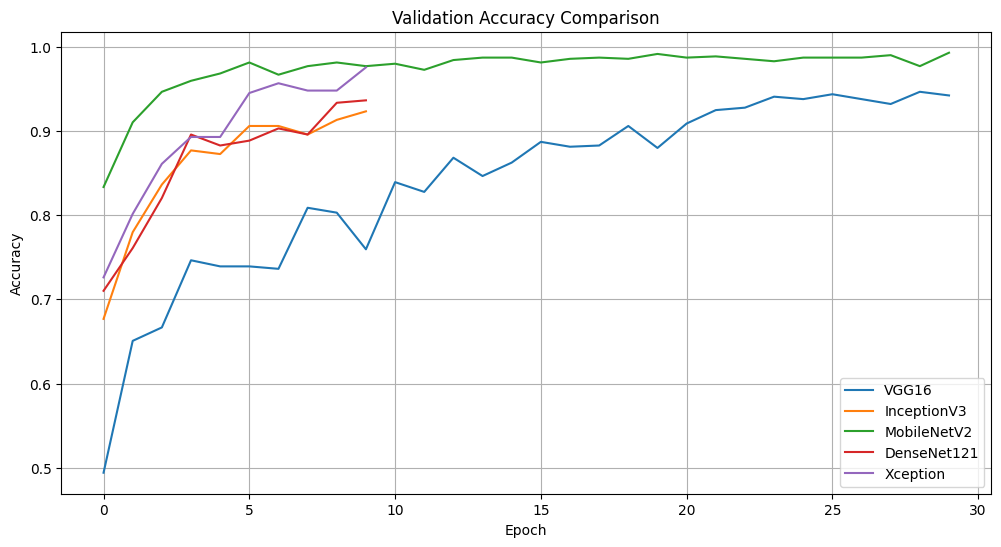

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy comparison
plt.figure(figsize=(12,6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Visualization

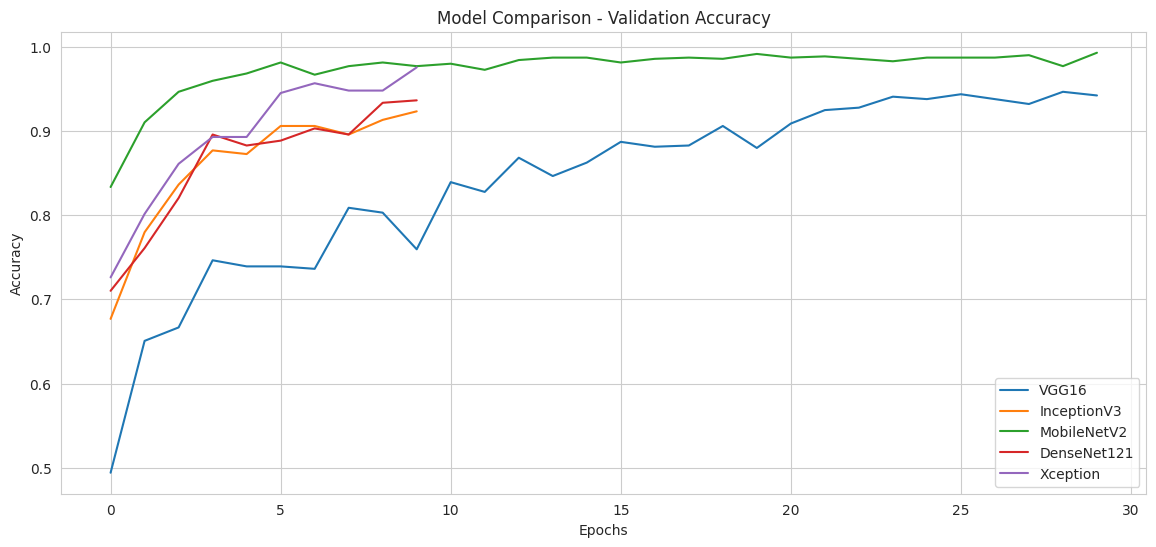

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 431ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step

Classification Report for VGG16
------------------------------------------------------------


,precision,recall,f1-score,support
Adenocarcinoma,0.930435,0.930435,0.930435,115.000000
Benign,0.961538,0.869565,0.913242,115.000000
Large_Cell_Carcinoma,0.973214,0.947826,0.960352,115.000000
Malignant,0.974576,1.000000,0.987124,115.000000
Normal,0.873016,0.956522,0.912863,115.000000
Squamous_Cell_Carcinoma,0.947826,0.947826,0.947826,115.000000
accuracy,0.942029,0.942029,0.942029,0.942029
macro avg,0.943434,0.942029,0.941974,690.000000
weighted avg,0.943434,0.942029,0.941974,690.000000





Classification Report for InceptionV3
------------------------------------------------------------


,precision,recall,f1-score,support
Adenocarcinoma,0.969697,0.278261,0.432432,115.000000
Benign,0.868421,0.573913,0.691099,115.000000
Large_Cell_Carcinoma,0.484979,0.982609,0.649425,115.000000
Malignant,0.941176,0.834783,0.884793,115.000000
Normal,0.612903,0.826087,0.703704,115.000000
Squamous_Cell_Carcinoma,0.714286,0.565217,0.631068,115.000000
accuracy,0.676812,0.676812,0.676812,0.676812
macro avg,0.765244,0.676812,0.665420,690.000000
weighted avg,0.765244,0.676812,0.665420,690.000000





Classification Report for MobileNetV2
------------------------------------------------------------


...

,precision,recall,f1-score,support
Adenocarcinoma,0.544872,0.739130,0.627306,115.000000
Benign,0.696552,0.878261,0.776923,115.000000
Large_Cell_Carcinoma,0.797101,0.478261,0.597826,115.000000
Malignant,0.883333,0.921739,0.902128,115.000000
Normal,0.662791,0.495652,0.567164,115.000000
Squamous_Cell_Carcinoma,0.754386,0.747826,0.751092,115.000000
accuracy,0.710145,0.710145,0.710145,0.710145
macro avg,0.723172,0.710145,0.703740,690.000000
weighted avg,0.723172,0.710145,0.703740,690.000000





Classification Report for Xception
------------------------------------------------------------


,precision,recall,f1-score,support
Adenocarcinoma,0.702703,0.452174,0.550265,115.000000
Benign,0.637931,0.965217,0.768166,115.000000
Large_Cell_Carcinoma,0.586957,0.939130,0.722408,115.000000
Malignant,0.921053,0.913043,0.917031,115.000000
Normal,0.862745,0.382609,0.530120,115.000000
Squamous_Cell_Carcinoma,0.870968,0.704348,0.778846,115.000000
accuracy,0.726087,0.726087,0.726087,0.726087
macro avg,0.763726,0.726087,0.711139,690.000000
weighted avg,0.763726,0.726087,0.711139,690.000000





Model Performance Summary
------------------------------------------------------------


,Model,Accuracy,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Weighted Avg F1
2,MobileNetV2,0.991304,0.991342,0.991304,0.991304,0.991304
0,VGG16,0.942029,0.943434,0.942029,0.941974,0.941974
4,Xception,0.726087,0.763726,0.726087,0.711139,0.711139
3,DenseNet121,0.710145,0.723172,0.710145,0.703740,0.703740
1,InceptionV3,0.676812,0.765244,0.676812,0.665420,0.665420


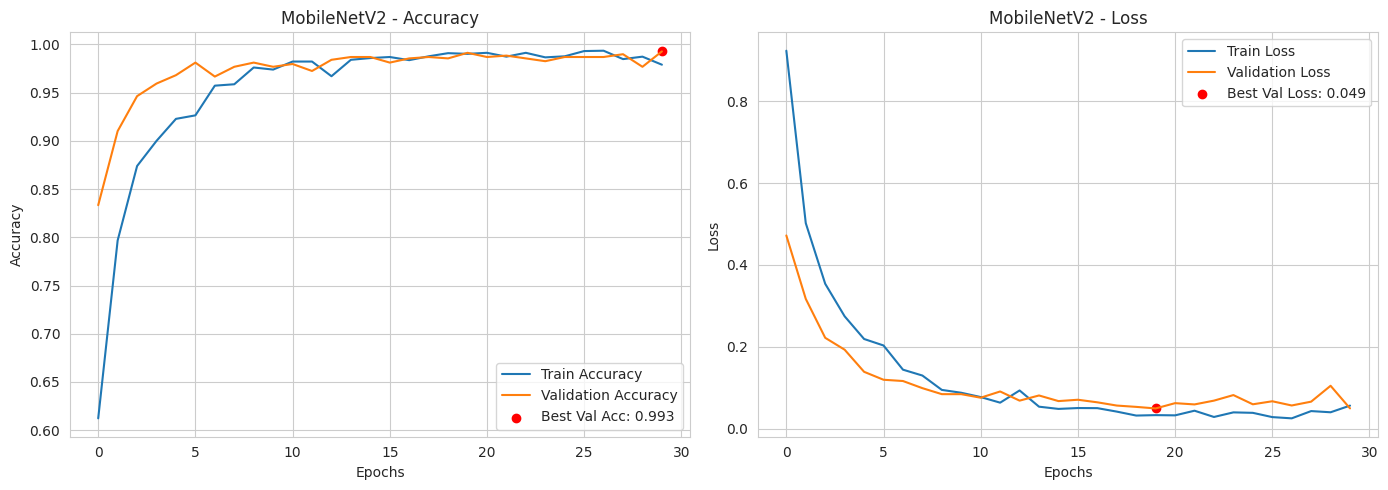

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


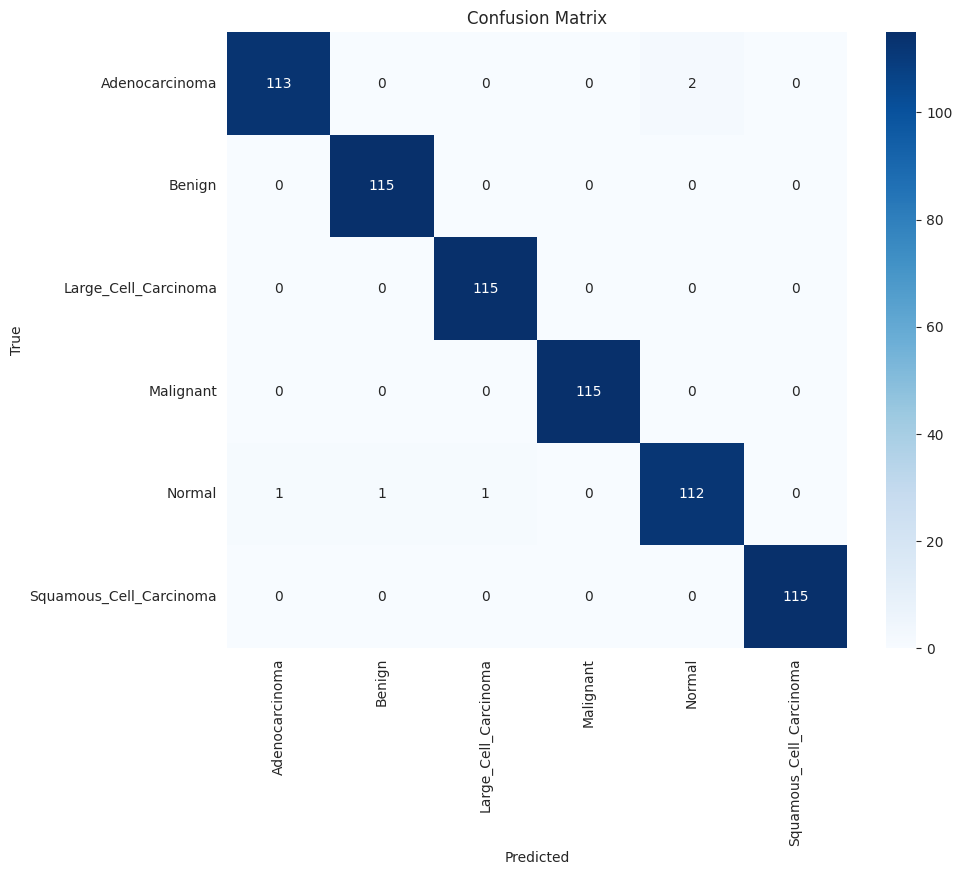


Best Model: MobileNetV2

Final Training Accuracy: 0.9790
Final Validation Accuracy: 0.9928
Best Validation Accuracy: 0.9928


In [25]:
 

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Model Comparison Plot
plt.figure(figsize=(14, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.title('Model Comparison - Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

from sklearn.metrics import classification_report
import pandas as pd

# Initialize a dictionary to store all reports
all_reports = {}

# 2.  Generate classification report for each model
for model_name in models.keys():
    # Load the model (if not already in memory)
    model = load_model(f'{model_name}_model.keras')
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test_onehot, axis=1)
    
    # Generate classification report
    report = classification_report(y_true, y_pred_classes, 
                                 target_names=class_names,
                                 output_dict=True)
    
    # Convert to DataFrame for better display and store
    report_df = pd.DataFrame(report).transpose()
    all_reports[model_name] = report_df

# Display all reports in a clean format
for model_name, report in all_reports.items():
    print(f"\n\033[1mClassification Report for {model_name}\033[0m")
    print("-" * 60)
    display(report.style.background_gradient(cmap='Blues', axis=0, 
                                          subset=pd.IndexSlice['precision':'f1-score', :]))
    print("\n")

# Optionally: Create a summary comparison of key metrics
summary_data = []
for model_name, report in all_reports.items():
    summary_data.append({
        'Model': model_name,
        'Accuracy': report.loc['accuracy', 'precision'],
        'Macro Avg Precision': report.loc['macro avg', 'precision'],
        'Macro Avg Recall': report.loc['macro avg', 'recall'],
        'Macro Avg F1': report.loc['macro avg', 'f1-score'],
        'Weighted Avg F1': report.loc['weighted avg', 'f1-score']
    })

summary_df = pd.DataFrame(summary_data)
print("\n\033[1mModel Performance Summary\033[0m")
print("-" * 60)
display(summary_df.sort_values('Accuracy', ascending=False)
       .style.background_gradient(cmap='YlOrBr', subset=['Accuracy']))



# 3. Training Curves for Best Model (based on validation accuracy)
best_model_name = max(histories.items(), key=lambda x: max(x[1].history['val_accuracy']))[0]
best_history = histories[best_model_name]

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
max_acc = max(best_history.history['val_accuracy'])
max_acc_epoch = np.argmax(best_history.history['val_accuracy'])
plt.scatter(max_acc_epoch, max_acc, c='red', label=f'Best Val Acc: {max_acc:.3f}')
plt.title(f'{best_model_name} - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
min_loss = min(best_history.history['val_loss'])
min_loss_epoch = np.argmin(best_history.history['val_loss'])
plt.scatter(min_loss_epoch, min_loss, c='red', label=f'Best Val Loss: {min_loss:.3f}')
plt.title(f'{best_model_name} - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Confusion Matrix
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



# 5. Print model summary and final metrics
print(f"\nBest Model: {best_model_name}")

final_train_acc = best_history.history['accuracy'][-1]
final_val_acc = best_history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Best Validation Accuracy: {max_acc:.4f}")

# Grad-CAM

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Clinical Prediction: Malignant (Confidence: 100.0%)


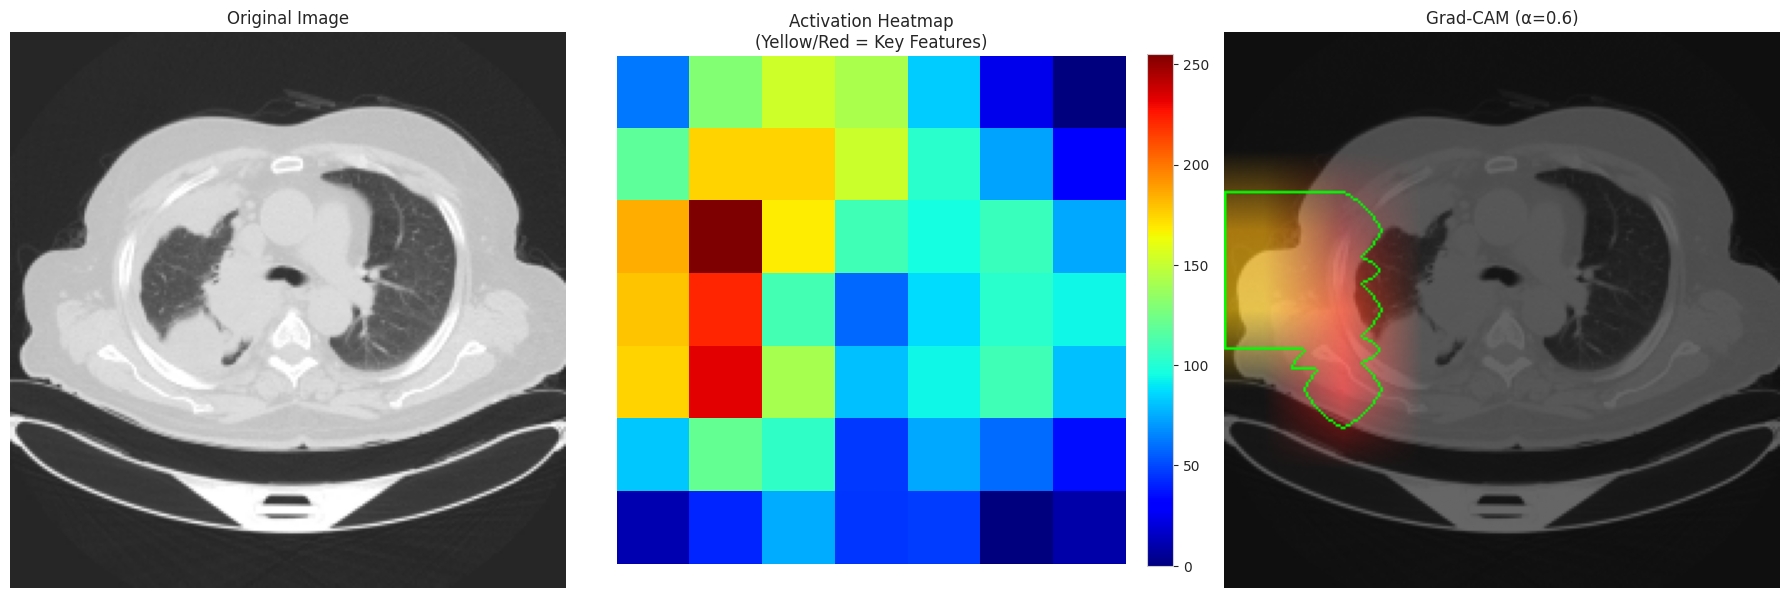

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras import backend as K
from matplotlib import colormaps


# load model
model = load_model('/kaggle/working/best_transfer_model.keras')

# Function to preprocess image for MobileNetV2
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # MobileNetV2 expects inputs in [0,1]
    return x

# Function to make prediction and get class
def predict_class(img_array, model, class_names):
    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    class_name = class_names[class_idx]
    confidence = preds[0][class_idx]
    return class_name, confidence, class_idx

# Grad-CAM implementation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Updated Grad-CAM visualization function
def display_gradcam(img_path, heatmap, alpha=0.5, focus_threshold=0.5):
    # Load and preprocess original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    
    # Rescale and threshold heatmap
    heatmap = np.uint8(255 * heatmap)
    
    # Get colormap (updated to remove deprecation warning)
    jet = colormaps['jet']
    
    # Create heatmap with focus threshold
    heatmap_normalized = heatmap / 255.0
    focus_mask = heatmap_normalized > focus_threshold
    jet_heatmap = jet(heatmap_normalized)[..., :3]  # Get RGB only
    jet_heatmap[~focus_mask] = 0  # Zero out non-focused areas
    
    # Resize heatmap to match image
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))
    
    # Enhanced superposition with contour highlighting
    superimposed_img = (jet_heatmap * alpha + img/255.0 * (1 - alpha))
    
    # Create figure with medical interpretation-friendly layout
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    ax1.imshow(img)
    ax1.set_title("Original Image", fontsize=12)
    ax1.axis('off')
    
    # Heatmap with medical relevance indicators
    hmap = ax2.imshow(heatmap, cmap='jet')
    ax2.set_title("Activation Heatmap\n(Yellow/Red = Key Features)", fontsize=12)
    plt.colorbar(hmap, ax=ax2, fraction=0.046, pad=0.04)
    ax2.axis('off')
    
    # Enhanced Grad-CAM with focus areas
    ax3.imshow(superimposed_img)
    ax3.set_title(f"Grad-CAM (α={alpha})", fontsize=12)
    
    # Add contour lines for medical feature delineation
    if focus_mask.sum() > 0:  # Only if we have focused areas
        resized_mask = cv2.resize(focus_mask.astype(np.uint8), 
                                (img.shape[1], img.shape[0]))
        contours, _ = cv2.findContours(resized_mask, 
                                     cv2.RETR_TREE, 
                                     cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            cv2.drawContours(superimposed_img, [contour], -1, (0, 1, 0), 1)
        ax3.imshow(superimposed_img)
    
    ax3.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage with medical image
def interpret_medical_image(img_path, model, class_names):
    # Preprocess
    img_array = preprocess_image(img_path)
    
    # Predict
    class_name, confidence, class_idx = predict_class(img_array, model, class_names)
    print(f"\nClinical Prediction: {class_name} (Confidence: {confidence:.1%})")
    
    # Generate heatmap - adjust layer name as needed
    last_conv_layer_name = "Conv_1"  # MobileNetV2 specific
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    
    # Enhanced medical visualization
    display_gradcam(img_path, heatmap, alpha=0.6, focus_threshold=0.7)
    


class_names = ['Adenocarcinoma', 'Benign', 'Large_Cell_Carcinoma', 'Malignant', 'Normal', 'Squamous_Cell_Carcinoma']

# Usage example:
interpret_medical_image('/kaggle/input/lung-ct-scans/Lung_CT/Malignant/Malignant case (20).jpg', model, class_names)